# Install Required Tools

In [1]:
pip install pandas numpy matplotlib seaborn openpyxl

# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [4]:
df = pd.read_excel("/content/Dataset for Data Analytics (1).xlsx")

# View Dataset

In [5]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


# Check Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

# Check Missing Values

In [7]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


# Generate Basic Statistics

In [8]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


# Product Revenue Analysis

In [9]:
product_sales = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

print(product_sales)

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64


# Visualize Product Revenue

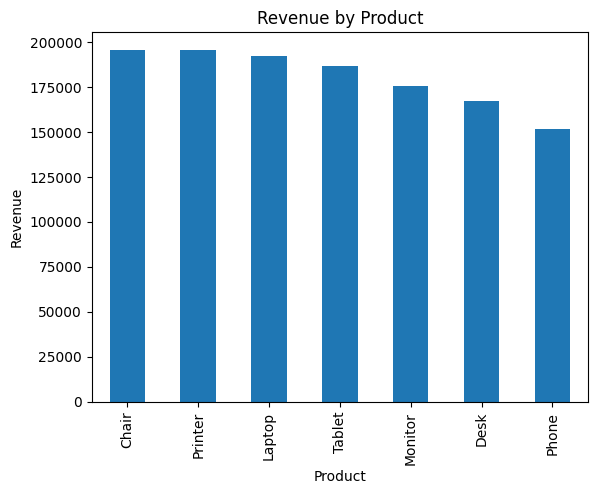

In [10]:
product_sales.plot(kind='bar')

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.show()

# Payment Method Analysis

In [11]:
payment = df['PaymentMethod'].value_counts()

print(payment)

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


## Create Pie Chart

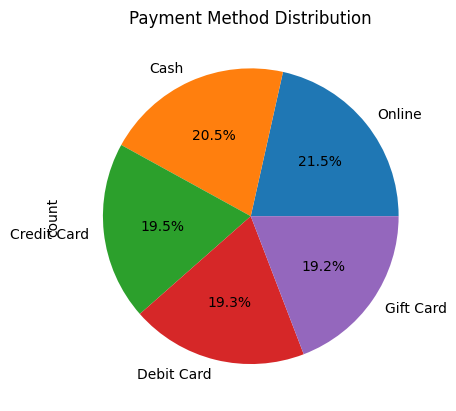

In [12]:
payment.plot(kind='pie', autopct='%1.1f%%')

plt.title("Payment Method Distribution")

plt.show()

# Order Status Analysis

In [13]:
status = df['OrderStatus'].value_counts()

print(status)

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


## Create Count Plot

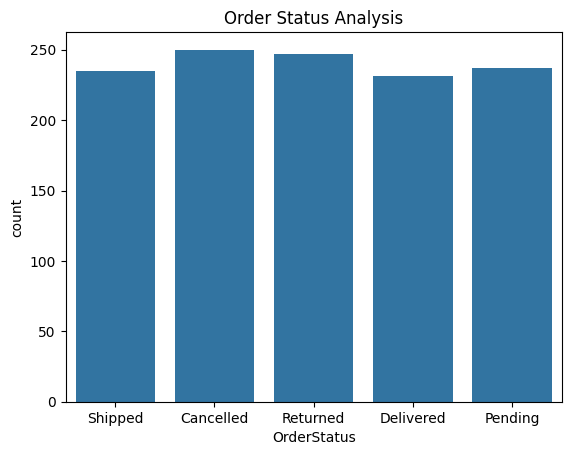

In [14]:
sns.countplot(x='OrderStatus', data=df)

plt.title("Order Status Analysis")

plt.show()

# Referral Source Analysis

In [15]:
referral = df['ReferralSource'].value_counts()

print(referral)

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64


# Monthly Sales Trend

In [16]:
df['Date'] = pd.to_datetime(df['Date'])

monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['TotalPrice'].sum()

print(monthly_sales)

Date
2023-01    56685.75
2023-02    40117.66
2023-03    48609.37
2023-04    27751.71
2023-05    63836.84
2023-06    49500.19
2023-07    42820.66
2023-08    54352.14
2023-09    29526.67
2023-10    52607.85
2023-11    43079.67
2023-12    43754.73
2024-01    38528.08
2024-02    36909.57
2024-03    36030.90
2024-04    49613.14
2024-05    27909.11
2024-06    68068.54
2024-07    42963.98
2024-08    31991.07
2024-09    39794.98
2024-10    37226.97
2024-11    32413.76
2024-12    38785.77
2025-01    29099.40
2025-02    35317.55
2025-03    39200.66
2025-04    31821.20
2025-05    43396.64
2025-06    53047.40
Freq: M, Name: TotalPrice, dtype: float64


## Create Trend Line Chart

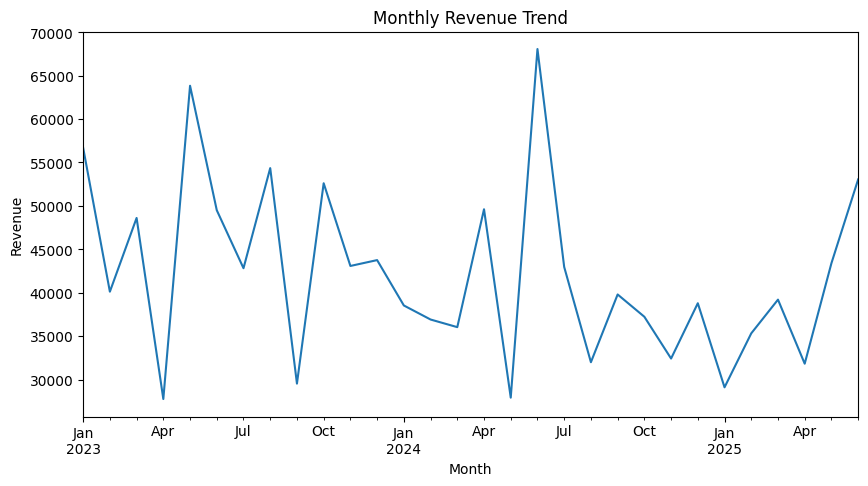

In [17]:
monthly_sales.plot(figsize=(10,5))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

# Outlier Detection

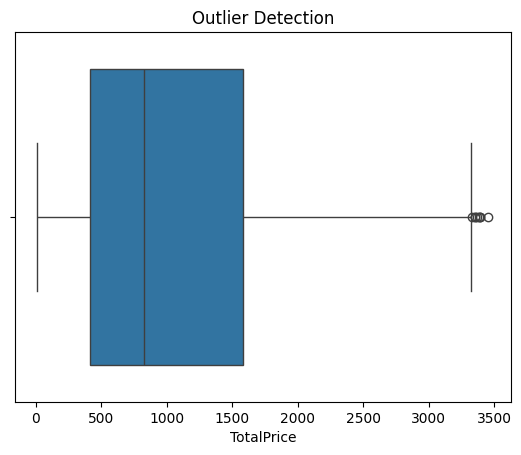

In [18]:
sns.boxplot(x=df['TotalPrice'])

plt.title("Outlier Detection")

plt.show()